In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
rng = np.random.default_rng(423)

In [3]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("../HEK293T/TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("../HEK293T/TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("../HEK293T/TotalX_HEK293T_capture.txt")

In [4]:
# load results
ind_MF_df = pd.read_csv("../HEK293T/Results/New/independent_MF.csv", index_col=0)
int_MF_df = pd.read_csv("../HEK293T/Results/New/interacting_MF.csv", index_col=0)
corr_df = pd.read_csv("../HEK293T/Results/New/correlation.csv", index_col=0)

In [5]:
# choose miRNA
miRNA = "MIR4709" # "MIR3655"

# select results
ind = ind_MF_df[f'{miRNA}_status']
mid = int_MF_df[f'{miRNA}_HAR_mid']

In [6]:
# size
M = 5

# get names of negatively correlated interacting pcRNA
names_neg = mid[mid < -0.25].index.tolist()
names_neg = rng.choice(names_neg, size=M, replace=False)

names_neg

array(['OXR1', 'JPH1', 'NFIB', 'SET', 'SRSF6'], dtype='<U15')

In [7]:
names_neg = np.array(['MIR4709', 'LRBA', 'PWWP2A', 'IMMP2L', 'WDR76', 'ZNF557'])

In [8]:
# subset adata
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]
adata_miRNA_chosen = adata_miRNA[:, adata_miRNA.var['GeneName'] == miRNA]

# combine 
adata_chosen = ad.concat([adata_miRNA_chosen, adata_neg], axis=1)

# Correlation

In [9]:
# select all gene pairs: no repeats
Is, Js = np.triu_indices(M + 1, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# construct dataset
SDP_data = SDP_miRNA.dataset.Dataset()
SDP_data.construct_dataset_adata(adata_chosen, adata_chosen, beta, gene_queries)

# bootstrap
SDP_data.bootstrap(d=3)

100%|██████████| 1/1 [00:00<00:00,  1.48it/s]


In [10]:
# model free independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data, d=3)
MF_ind.optimized_construction = True
MF_ind.analyse_dataset()

100%|██████████| 15/15 [00:00<00:00, 76.07it/s]


In [11]:
# model free interacting H&R
MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data, d=3)
MF_int.analyse_dataset()

100%|██████████| 15/15 [00:05<00:00,  2.54it/s]


In [12]:
# H&R correlations
HAR_points, HAR_intervals = MF_int.compute_dataset_correlation()
HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

100%|██████████| 15/15 [00:00<00:00, 107.98it/s]


In [13]:
# correlation
OB, AL = SDP_miRNA.correlation.compute_correlations(SDP_data)

100%|██████████| 1/1 [00:00<00:00,  3.53it/s]


In [14]:
OB_matrix = np.zeros((M + 1, M + 1))
AL_matrix = np.zeros((M + 1, M + 1))
HAR_matrix = np.zeros((M + 1, M + 1))
for i, query in enumerate(SDP_data.gene_queries):
    if MF_ind.result_dict[i]['status'] == "INFEASIBLE":
        OB_matrix[query[0][0], query[1][0]] = OB[i, 0]
        AL_matrix[query[0][0], query[1][0]] = AL[i, 0]
        HAR_matrix[query[0][0], query[1][0]] = HAR_mid[i]

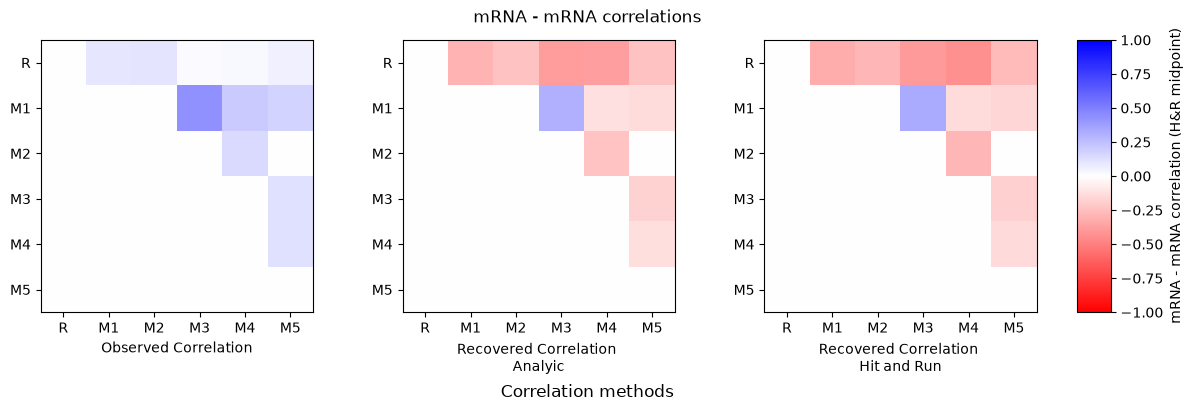

In [ ]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 4, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(OB_matrix, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(AL_matrix, cmap=cmap, vmin=-1, vmax=1)
im = axs[2].imshow(HAR_matrix, cmap=cmap, vmin=-1, vmax=1)
axs[0].set_xlabel("Observed Correlation")
axs[1].set_xlabel("Recovered Correlation \nAnalyic")
axs[2].set_xlabel("Recovered Correlation \nHit and Run")
RNA_labels = ["R"] + [f"M{i + 1}" for i in range(M)]
for i in range(3):
    axs[i].set_xticks(range(M + 1))
    axs[i].set_xticklabels(RNA_labels)
    axs[i].set_yticks(range(M + 1))
    axs[i].set_yticklabels(RNA_labels)
fig.supxlabel("Correlation methods")
fig.suptitle("mRNA - mRNA correlations")
plt.colorbar(im, cax=axs[3], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()

# Models

In [16]:
class Optimization_BD_MRR(SDP_miRNA.optimization.Optimization):

    def __init__(self, dataset, targets, **kwargs):

        # preset settings
        constraints = SDP_miRNA.constraints.Constraint(
            moment_bounds=True,
            moment_matrices=True,
            moment_equations=True
        )
        reactions = [
            "1",
            "xs[0]"
        ]
        for i in range(targets):
            reactions += [
                "1",
                f"xs[{i + 1}]",
                f"xs[0] * xs[{i + 1}]"
            ]

        stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
        stoch_out = np.zeros((2 + targets * 3, 1 + targets))
        stoch_out[0, 0] = 1
        stoch_inp[1, 0] = 1
        for m in range(targets):
            r = 2 + 3 * m
            s = 1 + m
            stoch_out[r, s] = 1
            stoch_inp[r + 1, s] = 1
            stoch_inp[r + 2, 0] = 1
            stoch_inp[r + 2, s] = 1
            stoch_out[r + 2, 0] = 1

        vrs = stoch_out - stoch_inp
        db = 2
        R = len(reactions)
        S = 1 + targets
        U = []

        # default fixed rate
        if not ('rate_fixed' in kwargs.keys()):
            kwargs['rate_fixed'] = [(1, 1)]

        # initialize superclass
        super().__init__(
            dataset,
            constraints,
            reactions,
            vrs,
            db,
            R,
            S,
            U,
            **kwargs
        )

In [17]:
class Optimization_BD_MR0(SDP_miRNA.optimization.Optimization):

    def __init__(self, dataset, targets, **kwargs):

        # preset settings
        constraints = SDP_miRNA.constraints.Constraint(
            moment_bounds=True,
            moment_matrices=True,
            moment_equations=True
        )
        reactions = [
            "1",
            "xs[0]"
        ]
        for i in range(targets):
            reactions += [
                "1",
                f"xs[{i + 1}]",
                f"xs[0] * xs[{i + 1}]"
            ]

        stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
        stoch_out = np.zeros((2 + targets * 3, 1 + targets))
        stoch_out[0, 0] = 1
        stoch_inp[1, 0] = 1
        for m in range(targets):
            r = 2 + 3 * m
            s = 1 + m
            stoch_out[r, s] = 1
            stoch_inp[r + 1, s] = 1
            stoch_inp[r + 2, 0] = 1
            stoch_inp[r + 2, s] = 1

        vrs = stoch_out - stoch_inp
        db = 2
        R = len(reactions)
        S = 1 + targets
        U = []

        # default fixed rate
        if not ('rate_fixed' in kwargs.keys()):
            kwargs['rate_fixed'] = [(1, 1)]

        # initialize superclass
        super().__init__(
            dataset,
            constraints,
            reactions,
            vrs,
            db,
            R,
            S,
            U,
            **kwargs
        )

## (R, M[1-5])

In [18]:
# set gene queries
gene_queries = [
    [[t for t in range(1 + M)], []]
]
SDP_data.gene_queries = gene_queries
SDP_data.total_gene_queries = len(gene_queries)

# bootstrap
SDP_data.bootstrap(d=3)

# optimize
BD_MRR_opt = Optimization_BD_MRR(SDP_data, M, d=3)
BD_MRR_opt.optimized_construction = True
BD_MRR_opt.analyse_dataset()

BD_MRR_opt.result_dict[0]['status']

100%|██████████| 1/1 [00:00<00:00,  5.79it/s]


'INFEASIBLE'

In [19]:
# set gene queries
gene_queries = [
    [[t for t in range(1 + M)], []]
]
SDP_data.gene_queries = gene_queries
SDP_data.total_gene_queries = len(gene_queries)

# bootstrap
SDP_data.bootstrap(d=3)

# optimize
BD_MR0_opt = Optimization_BD_MR0(SDP_data, M, d=3)
BD_MR0_opt.optimized_construction = True
BD_MR0_opt.analyse_dataset()

BD_MR0_opt.result_dict[0]['status']

100%|██████████| 1/1 [00:00<00:00,  4.86it/s]


'INFEASIBLE'

## (R, Mi, Mj)

In [47]:
# select all gene pairs: no repeats
Is, Js = np.triu_indices(M + 1, k=1)
gene_queries = [
    [[0, int(i), int(j)], []] for i, j in zip(Is, Js) if i > 0
]
SDP_data.gene_queries = gene_queries
SDP_data.total_gene_queries = len(gene_queries)

# bootstrap
SDP_data.bootstrap(d=3)

# optimize
BD_MRR_opt = Optimization_BD_MRR(SDP_data, 2, d=3)
BD_MRR_opt.optimized_construction = True
BD_MRR_opt.analyse_dataset()

# optimize
BD_MR0_opt = Optimization_BD_MR0(SDP_data, 2, d=3)
BD_MR0_opt.optimized_construction = True
BD_MR0_opt.analyse_dataset()

100%|██████████| 10/10 [05:00<00:00, 30.05s/it]


In [48]:
MRR_matrix = np.zeros((M + 1, M + 1))
MR0_matrix = np.zeros((M + 1, M + 1))
for i, query in enumerate(SDP_data.gene_queries):
    if BD_MRR_opt.result_dict[i]['status'] == "OPTIMAL":
        MRR_matrix[query[0][1], query[0][2]] = 1
    elif BD_MRR_opt.result_dict[i]['status'] == "INFEASIBLE":
        MRR_matrix[query[0][1], query[0][2]] = -1
    if BD_MR0_opt.result_dict[i]['status'] == "OPTIMAL":
        MR0_matrix[query[0][1], query[0][2]] = 1
    if BD_MR0_opt.result_dict[i]['status'] == "INFEASIBLE":
        MR0_matrix[query[0][1], query[0][2]] = -1

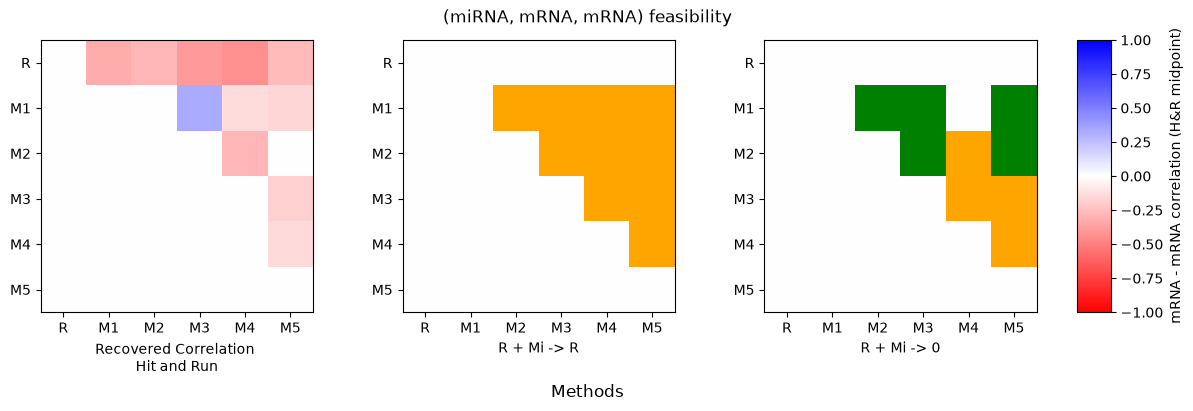

In [49]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
cmap_FEAS = LinearSegmentedColormap.from_list('a', ['orange', 'white', 'green'])
fig, axs = plt.subplots(1, 4, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1, 0.1]}, constrained_layout=True)
im_corr = axs[0].imshow(HAR_matrix, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(MRR_matrix, cmap=cmap_FEAS, vmin=-1, vmax=1)
im = axs[2].imshow(MR0_matrix, cmap=cmap_FEAS, vmin=-1, vmax=1)
axs[0].set_xlabel("Recovered Correlation \nHit and Run")
axs[1].set_xlabel("R + Mi -> R")
axs[2].set_xlabel("R + Mi -> 0")
RNA_labels = ["R"] + [f"M{i + 1}" for i in range(M)]
for i in range(3):
    axs[i].set_xticks(range(M + 1))
    axs[i].set_xticklabels(RNA_labels)
    axs[i].set_yticks(range(M + 1))
    axs[i].set_yticklabels(RNA_labels)
fig.supxlabel("Methods")
fig.suptitle("(miRNA, mRNA, mRNA) feasibility")
plt.colorbar(im_corr, cax=axs[3], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()

## (R, Mi)

In [50]:
# select
gene_queries = [
    [[0, int(i)], []] for i in range(1, M + 1)
]
SDP_data.gene_queries = gene_queries
SDP_data.total_gene_queries = len(gene_queries)

# bootstrap
SDP_data.bootstrap(d=3)

# optimize
BD_MRR_opt = Optimization_BD_MRR(SDP_data, 1, d=3)
BD_MRR_opt.optimized_construction = True
BD_MRR_opt.analyse_dataset()

# optimize
BD_MR0_opt = Optimization_BD_MR0(SDP_data, 1, d=3)
BD_MR0_opt.optimized_construction = True
BD_MR0_opt.analyse_dataset()

100%|██████████| 5/5 [00:00<00:00, 41.57it/s]


In [51]:
BD_MRR_opt.result_dict

{0: {'status': 'INFEASIBLE', 'time': 0.0010001659393310547, 'cuts': 0},
 1: {'status': 'INFEASIBLE', 'time': 0.0, 'cuts': 0},
 2: {'status': 'INFEASIBLE', 'time': 0.0009999275207519531, 'cuts': 0},
 3: {'status': 'INFEASIBLE', 'time': 0.0, 'cuts': 0},
 4: {'status': 'INFEASIBLE', 'time': 0.0, 'cuts': 0}}

In [52]:
BD_MR0_opt.result_dict

{0: {'status': 'OPTIMAL', 'time': 0.004999876022338867, 'cuts': 0},
 1: {'status': 'OPTIMAL', 'time': 0.003000020980834961, 'cuts': 0},
 2: {'status': 'OPTIMAL', 'time': 0.0029997825622558594, 'cuts': 0},
 3: {'status': 'OPTIMAL', 'time': 0.003000020980834961, 'cuts': 0},
 4: {'status': 'OPTIMAL', 'time': 0.002000093460083008, 'cuts': 0}}